# Exploratory Data Analysis

## Setup

In [1039]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns

In [1040]:
path = "/Users/sofiascaiano/Documents/maestria/TT1/project/scraper_cnv/calificaciones.csv"

In [1041]:
def cleaner(texto):
    if pd.isna(texto) or texto == "":
        return np.nan

    # 1. Normalización NFD para separar tildes de las letras
    texto = unicodedata.normalize('NFD', str(texto))
    # 2. Eliminar tildes filtrando caracteres de categoría 'Mn' (Non-Spacing Mark)
    texto = "".join([c for c in texto if unicodedata.category(c) != 'Mn'])
    # 3. Volver a normalizar a NFKC (recomendado para compatibilidad)
    texto = unicodedata.normalize('NFKC', texto)

    # 4. Limpieza con Regex
    texto = texto.lower()
    # Mantenemos letras, números y caracteres clave de calificación (. y -)
    # Si preferís solo letras, usá r'[^a-z\s]'
    texto = re.sub(r'[^a-z0-9\.\-\s]', ' ', texto)

    # 5. Eliminar todos los espacios
    texto = re.sub(r'\s+', '', texto)

    return texto

In [1042]:
def calificacion_cleaner(texto):
    if pd.isna(texto):
        return ""

    texto = str(texto).lower()

    # 1. ELIMINAR TÉRMINOS CON PUNTOS (Hacerlo primero)
    # Usamos re.escape para que los puntos se traten como puntos reales y no como comodines
    terminos_especiales = ['p.b.']
    for termino in terminos_especiales:
        texto = texto.replace(termino, '')

    # 2. ELIMINAR PALABRAS RUIDO (Sin puntos)
    palabras_ruido = [
        'ml', 'ra', 'sf', 'varios', 'varias', 'arg', 'ar',
        'nacional', 'largo', 'corto'
    ]
    patron_palabras = r'\b(' + '|'.join(palabras_ruido) + r')\b'
    texto = re.sub(patron_palabras, '', texto)

    # 3. ELIMINAR CUALQUIER OTRO SÍMBOLO (Paréntesis, puntos sobrantes, comas)
    # Si agregás el punto '.' acá, se llevará cualquier punto que haya quedado
    simbolos_a_eliminar = r'[\(\)\.\,\/]'
    texto = re.sub(simbolos_a_eliminar, '', texto)

    # 4. LIMPIEZA FINAL DE ESPACIOS
    texto = re.sub(r'\s+', '', texto).strip()

    return texto.upper()

In [1043]:
def graficar_heatmap_transiciones_fix(data):
    # 2. Creamos la columna del rating anterior (t-1)
    data['rating_num_anterior'] = data.groupby(['cuit', 'plazo', 'moneda_a_calificar'])['rating_num'].shift(1)

    # 3. Filtramos para quedarnos SOLO con los cambios efectivos (volatilidad)
    df_cambios = data[data['evento_crediticio'].isin(['Upgrade', 'Downgrade'])].copy()

    # Evitamos el IntCastingNaNError
    df_cambios = df_cambios.dropna(subset=['rating_num_anterior', 'rating_num'])

    # Convertimos los floats a enteros
    df_cambios['rating_num_anterior'] = df_cambios['rating_num_anterior'].astype(int)
    df_cambios['rating_num'] = df_cambios['rating_num'].astype(int)

    # 4. Creamos la matriz cruzando rating anterior (filas) vs rating actual (columnas)
    matriz_freq = pd.crosstab(df_cambios['rating_num_anterior'], df_cambios['rating_num'])

    # 5. Reindexamos la matriz del 22 al 1 (AAA arriba, D abajo)
    escala_completa = list(range(22, 0, -1))
    matriz_freq = matriz_freq.reindex(index=escala_completa, columns=escala_completa, fill_value=0)

    # Limpiamos filas y columnas vacías
    matriz_freq = matriz_freq.loc[(matriz_freq.sum(axis=1) > 0), (matriz_freq.sum(axis=0) > 0)]

    # Guardamos los índices numéricos para las máscaras
    indices_num = list(matriz_freq.index)
    columnas_num = list(matriz_freq.columns)

    # 6. Mapeo inverso de números a letras para los ejes
    mapeo_ejes = {
        22: 'AAA', 21: 'AA+', 20: 'AA', 19: 'AA-', 18: 'A+', 17: 'A', 16: 'A-',
        15: 'BBB+', 14: 'BBB', 13: 'BBB-', 12: 'BB+', 11: 'BB', 10: 'BB-',
        9: 'B+', 8: 'B', 7: 'B-', 6: 'CCC+', 5: 'CCC', 4: 'CCC-', 3: 'CC', 2: 'C', 1: 'D/RD'
    }

    matriz_freq.index = matriz_freq.index.map(mapeo_ejes)
    matriz_freq.columns = matriz_freq.columns.map(mapeo_ejes)

    # 7. CONSTRUCCIÓN DE MÁSCARAS CORREGIDAS (Lógica inversa por índice AAA->D)
    mask_upgrade = pd.DataFrame(True, index=matriz_freq.index, columns=matriz_freq.columns)
    mask_downgrade = pd.DataFrame(True, index=matriz_freq.index, columns=matriz_freq.columns)

    for i, r_ant in enumerate(indices_num):
        for j, r_act in enumerate(columnas_num):
            if r_act > r_ant:      # Numéricamente mayor = Nota más alta (UPGRADE) -> Región Inferior Izquierda
                mask_upgrade.iloc[i, j] = False
            elif r_act < r_ant:    # Numéricamente menor = Nota más baja (DOWNGRADE) -> Región Superior Derecha
                mask_downgrade.iloc[i, j] = False

    # 8. Graficado con barras de color prolijas (gridspec)
    sns.set_theme(style="white")
    plt.rcParams.update({'font.size': 9, 'axes.labelsize': 11})

    fig, ax = plt.subplots(figsize=(11, 8))

    # Ejes secundarios para las barras de color (cbar) alineadas con sus regiones reales
    ax_cbar_down = fig.add_axes([0.92, 0.55, 0.015, 0.33])  # Arriba a la derecha (Downgrades)
    ax_cbar_up = fig.add_axes([0.92, 0.15, 0.015, 0.33])    # Abajo a la derecha (Upgrades)

    # Región de DOWNGRADES (Rojo) - Se muestra arriba de la diagonal
    sns.heatmap(
        matriz_freq,
        mask=mask_downgrade,
        annot=True,
        fmt="d",
        cmap="Reds",
        cbar=True,
        cbar_ax=ax_cbar_down,
        cbar_kws={'label': 'Frecuencia Downgrades (Deterioros)'},
        linewidths=.5,
        annot_kws={"size": 9},
        ax=ax
    )

    # Región de UPGRADES (Azul) - Se muestra abajo de la diagonal
    sns.heatmap(
        matriz_freq,
        mask=mask_upgrade,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        cbar_ax=ax_cbar_up,
        cbar_kws={'label': 'Frecuencia Upgrades (Mejoras)'},
        linewidths=.5,
        annot_kws={"size": 9},
        ax=ax
    )

    # 9. Línea diagonal divisoria (Frontera de estabilidad)
    ax.plot([0, len(matriz_freq.columns)], [0, len(matriz_freq.index)], color='darkgray', linestyle=':', linewidth=2)

    # ax.set_title('Matriz de Transiciones Crediticias Efectivas (Asimétrica)', fontsize=13, pad=15, fontweight='bold')
    ax.set_xlabel('Calificación Posterior ($t$)', fontsize=11, labelpad=8)
    ax.set_ylabel('Calificación Anterior ($t-1$)', fontsize=11, labelpad=8)

    plt.subplots_adjust(right=0.89, left=0.10, top=0.92, bottom=0.12)

    plt.savefig('matriz_transiciones_global.png', dpi=300, bbox_inches='tight')
    plt.show()

In [1044]:
# 1. Definimos los diccionarios de mapeo maestro (se quedan igual que los tuyos)
mapeo_ratings_largo_plazo = {
    'AAA+': 24, 'AAA': 23, 'AAA-': 22, 'AA+': 21, 'AA': 20, 'AA-': 19,
    'A+': 18, 'A': 17, 'A-': 16, 'BBB+': 15, 'BBB': 14, 'BBB-': 13,
    'BB+': 12, 'BB': 11, 'BB-': 10, 'B+': 9, 'B': 8, 'B-': 7,
    'CCC+': 6, 'CCC': 5, 'CCC-': 4, 'CC': 3, 'C': 2, 'D': 1
}

mapeo_ratings_corto_plazo = {
    'A1+': 7, 'A-1+': 7, 'A1': 6, 'A-1': 6, 'A2': 5, 'A-2': 5,
    'A3': 4, 'A-3': 4, 'B': 3, 'C': 2, 'D': 1
}

# 2. Función modificada para procesar tu DataFrame
def procesar_ratings_tesis(df):
    # Aseguramos que las notas sean strings y removemos espacios en blanco
    df['nota_limpia_final'] = df['nota_limpia_final'].str.strip()

    # Aseguramos homogeneidad en la columna plazo (por si acaso hay mayúsculas/minúsculas)
    df['plazo'] = df['plazo'].str.strip().str.upper()

    # Aseguramos que la fecha sea datetime
    df['fecha_consejo'] = pd.to_datetime(df['fecha_consejo'])

    # Creamos la columna de período mensual (Formato: YYYY-MM)
    df['periodo_mensual'] = df['fecha_consejo'].dt.to_period('M')

    # --- NUEVA LÓGICA DE MAPEO DINÁMICO ---
    def asignar_rating_num(fila):
        nota = fila['nota_limpia_final']
        plazo = fila['plazo']

        # Ajusta los strings 'LARGO PLAZO' o 'CORTO PLAZO' según cómo estén en tu dataset
        if 'LARGO' in plazo:
            return mapeo_ratings_largo_plazo.get(nota, None)
        elif 'CORTO' in plazo:
            return mapeo_ratings_corto_plazo.get(nota, None)
        else:
            return None # Por si hay algún dato corrupto en la columna plazo

    # Aplicamos la función fila por fila (axis=1)
    df['rating_num'] = df.apply(asignar_rating_num, axis=1)
    # ---------------------------------------

    # Ordenamos cronológicamente por empresa para calcular los cambios
    df = df.sort_values(by=['cuit', 'fecha_consejo'])

    # Calculamos el Delta (cambio de escalones o notches)
    # Es CRUCIAL que agrupes por 'plazo' también para que no te reste una nota de corto plazo con una de largo
    df['delta_notches'] = df.groupby(['cuit', 'calificadora', 'plazo', 'moneda_a_calificar'])['rating_num'].diff()

    # Clasificamos el evento para el modelo de IFRS 9
    def clasificar_evento(delta):
        if pd.isna(delta): return 'Inicio'
        if delta > 0: return 'Upgrade'
        if delta < 0: return 'Downgrade'
        return 'Mantiene'

    df['evento_crediticio'] = df['delta_notches'].apply(clasificar_evento)

    return df

In [1045]:
instrumentos = ["calificaciondelargoplazo",
                "calificacioninstitucional",
                "calificacioninstitucionaldelargoplazo",
                "calificacioninstiucional",
                "emisorcortoplazo",
                "emisoralargoplazo",
                "emisoras",
                "emisorasacortoplazo",
                "emisorasalargoplazo",
                "endeudamientoacortoplazo"
                ]

columns = ['cuit', 'razon_social', 'calificadora', 'fecha_consejo', 'presentacion_id', 'instrumento', 'moneda_a_calificar','calificacion_categoria', 'calificacion_signo', 'rating_watch', 'perspectiva']

calificadoras = ['FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO', 'MOODY´S LOCAL AR ACR S.A.', 'S&P GLOBAL RATINGS ARGENTINA SRL, AGENTE DE CALIFICACIÓN DE RIESGO']

cuits_eliminar = [33693710559, 30718204549] # no es empresa, es FF

## Importacion

In [1046]:
df_raw = pd.read_csv(path)
df_raw = df_raw[columns]

In [1047]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9330 entries, 0 to 9329
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cuit                    9330 non-null   int64  
 1   razon_social            9330 non-null   str    
 2   calificadora            9330 non-null   str    
 3   fecha_consejo           9330 non-null   str    
 4   presentacion_id         9327 non-null   float64
 5   instrumento             8675 non-null   str    
 6   moneda_a_calificar      7588 non-null   str    
 7   calificacion_categoria  9330 non-null   str    
 8   calificacion_signo      2785 non-null   str    
 9   rating_watch            9327 non-null   str    
 10  perspectiva             9327 non-null   str    
dtypes: float64(1), int64(1), str(9)
memory usage: 801.9 KB


In [1048]:
df_raw['presentacion_id'].nunique()

2605

In [1049]:
df_raw['cuit'].nunique()

173

### Ajuste Inicial

In [1050]:
mascara = (df_raw['presentacion_id'].isin([3179760, 2986004, 3133161])) & (df_raw['instrumento'].isin(['Emisorasa Corto Plazo', 'Endeudamientoa Corto Plazo']))
df_raw.loc[mascara, 'calificacion_categoria'] = 'CORTO / NACIONAL / B(arg)'

mascara = (df_raw['presentacion_id'].isin([2901824]))
df_raw.loc[mascara, 'calificacion_categoria'] = 'LARGO / NACIONAL / AA(ARG)'

mascara = (df_raw['presentacion_id'].isin([3043653])) & (df_raw['instrumento'].isin(['Emisorasa Corto Plazo']))
df_raw.loc[mascara, 'calificacion_signo'] = '+'

mascara = (df_raw['presentacion_id'].isin([2986010])) & (df_raw['instrumento'].isin(['Emisorasa Corto Plazo']))
df_raw.loc[mascara, 'calificacion_signo'] = '+'

mascara = ((df_raw['presentacion_id'].isin([2924299])) & (df_raw['instrumento'].isin(['Emisorasa Largo Plazo'])))
df_raw.loc[mascara, 'moneda_a_calificar'] = 'PESO (ARGENTINA)'

mascara = ((df_raw['presentacion_id'].isin([2924299])) & (~df_raw['instrumento'].isin(['Emisorasa Largo Plazo'])))
df_raw.loc[mascara, 'moneda_a_calificar'] = 'DÓLAR (E.U.A.)'

for cuit in cuits_eliminar:
    df_raw = df_raw[df_raw['cuit'] != cuit] # NO ES EMPRESA ES UN FIDEICOMISO FINANCIERO

## Limpieza inicial

In [1052]:
df_raw['fecha_consejo'] = pd.to_datetime(df_raw['fecha_consejo'], format='%d/%m/%Y')
df_raw['instrumento'] = df_raw['instrumento'].apply(cleaner)
# 2. Eliminar espacios en blanco
df_raw['calificacion_signo'] = df_raw['calificacion_signo'].str.strip().replace('.', '')
# 3. Rellenar con nulos si NO es exactamente '+' o '-'
valores_permitidos = ['+', '-']
df_raw.loc[~df_raw['calificacion_signo'].isin(valores_permitidos), 'calificacion_signo'] = np.nan

df_raw['moneda_a_calificar'] = df_raw['moneda_a_calificar'].fillna(value='PESO (ARGENTINA)')

In [1053]:
# --- PROCESAMIENTO ---
# 1. Dividir en las 3 columnas solicitadas
# Expand=True crea automáticamente las columnas nuevas
df_raw[['plazo', 'escala', 'nota_sucia']] = df_raw['calificacion_categoria'].str.split('/', expand=True)

df_raw['plazo'] = np.where(df_raw['plazo'].isin(['-1', 'NINGUNO']), 'LARGO', df_raw['plazo'])

# 2. Limpiar la columna de la nota técnica
df_raw['nota_limpia'] = df_raw['nota_sucia'].apply(calificacion_cleaner)

# 3. Limpiar las columnas de Plazo y Escala (por si tienen espacios)
df_raw['plazo'] = df_raw['plazo'].str.strip()
df_raw['escala'] = df_raw['escala'].str.strip()

# 2. Identificar cuáles ya tienen signo
patron = r'[+\-]'
df_raw['tiene_signo'] = df_raw['nota_limpia'].str.contains(patron, na=False)

# 3. CONCATENACIÓN CONDICIONAL
df_raw['nota_limpia_final'] = np.where(
    df_raw['tiene_signo'],
    df_raw['nota_limpia'],
    df_raw['nota_limpia'].str.cat(df_raw['calificacion_signo'], sep='', na_rep='')
)

### Seleccion de calificaciones

* Se descartan las calificaciones a obligaciones negociables
* Filtro las tres calificadoras mas importantes

In [1054]:
df = df_raw.copy()
df = df.drop_duplicates(subset=['fecha_consejo', 'cuit', 'moneda_a_calificar', 'plazo', 'nota_limpia_final'], keep='first')
df = df[(df['instrumento'].isin(instrumentos)) | (df['instrumento'].isna())]
df = df[df['calificadora'].isin(calificadoras)]

In [1055]:
df['cuit'].nunique()

144

In [1056]:
len(df)

2854

In [1057]:
df['presentacion_id'].nunique()

1963

In [1058]:
df['nota_limpia_final'].value_counts()

nota_limpia_final
A       354
A-      319
AAA     264
AA      229
AA-     220
A+      216
A-1     163
BBB+    155
AA+     138
A1+     136
A2      110
BBB      98
D        76
A1       70
A-2      44
C        41
BBB-     38
CCC      33
B        33
BB       28
CC       16
CCC+     15
A3       15
BB+      14
B+       11
BB-       7
          5
A-3       2
B-        2
AAA-      1
2         1
Name: count, dtype: int64

In [1059]:
df[df['nota_limpia_final'] == 'A3']

,cuit,razon_social,calificadora,fecha_consejo,presentacion_id,instrumento,moneda_a_calificar,calificacion_categoria,calificacion_signo,rating_watch,perspectiva,plazo,escala,nota_sucia,nota_limpia,tiene_signo,nota_limpia_final
1623,30501062150,Celulosa Argentina,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2024-12-19,3296149.0,emisorasacortoplazo,PESO (ARGENTINA),CORTO / NACIONAL / A3(arg),NaN,0,0,CORTO,NACIONAL,A3(arg),A3,False,A3
1854,33711944899,Central Termica Roca S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-04-28,3352707.0,emisorasacortoplazo,PESO (ARGENTINA),CORTO / NACIONAL / A3(arg),NaN,0,0,CORTO,NACIONAL,A3(arg),A3,False,A3
1861,33711944899,Central Termica Roca S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-02-20,3321279.0,emisorasacortoplazo,PESO (ARGENTINA),CORTO / NACIONAL / A3(arg),NaN,0,0,CORTO,NACIONAL,A3(arg),A3,False,A3
1868,33711944899,Central Termica Roca S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-01-03,3300923.0,emisorasacortoplazo,PESO (ARGENTINA),CORTO / NACIONAL / A3(arg),NaN,0,0,CORTO,NACIONAL,A3(arg),A3,False,A3
3540,30682434720,Generacion Mediterranea S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-04-28,3352712.0,emisorasacortoplazo,PESO (ARGENTINA),CORTO / NACIONAL / A3(arg),NaN,0,0,CORTO,NACIONAL,A3(arg),A3,False,A3
3578,30682434720,Generacion Mediterranea S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-02-20,3321223.0,emisorasacortoplazo,PESO (ARGENTINA),CORTO / NACIONAL / A3(arg),NaN,0,0,CORTO,NACIONAL,A3(arg),A3,False,A3
3613,30682434720,Generacion Mediterranea S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-01-03,3300905.0,emisorasacortoplazo,PESO (ARGENTINA),CORTO / NACIONAL / A3(arg),NaN,0,0,CORTO,NACIONAL,A3(arg),A3,False,A3
6357,30714814229,PETROLERA ACONCAGUA ENERGIA SA,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-12-23,3459382.0,emisorasacortoplazo,PESO (ARGENTINA),CORTO / NACIONAL / A3(arg),NaN,0,0,CORTO,NACIONAL,A3(arg),A3,False,A3
6392,30714814229,PETROLERA ACONCAGUA ENERGIA SA,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-09-10,3413939.0,emisorasacortoplazo,PESO (ARGENTINA),CORTO / NACIONAL / A3(arg),NaN,0,0,CORTO,NACIONAL,A3(arg),A3,False,A3
6451,30714814229,PETROLERA ACONCAGUA ENERGIA SA,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-06-03,3371135.0,emisorasacortoplazo,PESO (ARGENTINA),CORTO / NACIONAL / A3(arg),NaN,2-Negativa,0,CORTO,NACIONAL,A3(arg),A3,False,A3


In [1060]:
df['calificadora'].value_counts()

calificadora
FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO                         1574
MOODY´S LOCAL AR ACR S.A.                                             1208
S&P GLOBAL RATINGS ARGENTINA SRL, AGENTE DE CALIFICACIÓN DE RIESGO      72
Name: count, dtype: int64

In [1061]:
df['plazo'].value_counts()

plazo
LARGO      2251
CORTO       602
NINGUNO       1
Name: count, dtype: int64

In [1062]:
df['moneda_a_calificar'].value_counts(dropna=False)

moneda_a_calificar
PESO (ARGENTINA)    2475
DÓLAR (E.U.A.)       379
Name: count, dtype: int64

In [1063]:
# Contamos cuántas notas distintas tiene cada CUIT
variacion_por_empresa = df.groupby('cuit')['nota_limpia_final'].nunique()

# Filtramos las que tienen más de 1 nota (es decir, cambiaron)
empresas_con_cambio = (variacion_por_empresa > 1).sum()

print(f"Total de empresas que cambiaron de rating: {empresas_con_cambio}")

Total de empresas que cambiaron de rating: 108


In [1064]:
df_final = procesar_ratings_tesis(df)

# 3. Verificación de errores
# Si alguna nota no se mapeó, es probable que tenga un formato no contemplado
notas_no_mapeadas = df_final[df_final['rating_num'].isna()]['nota_limpia_final'].unique()
print(f"Revisar estas notas: {notas_no_mapeadas}")

Revisar estas notas: <StringArray>
['2', '']
Length: 2, dtype: str


In [1065]:
df_final[df_final['plazo'] == 'LARGO']['evento_crediticio'].value_counts()

evento_crediticio
Mantiene     1744
Inicio        239
Upgrade       143
Downgrade     125
Name: count, dtype: int64

In [1066]:
df_final[df_final['plazo'] == 'CORTO']['evento_crediticio'].value_counts()

evento_crediticio
Mantiene     493
Inicio        68
Downgrade     32
Upgrade        9
Name: count, dtype: int64

In [1067]:
df_final['evento_crediticio'].value_counts()

evento_crediticio
Mantiene     2237
Inicio        308
Downgrade     157
Upgrade       152
Name: count, dtype: int64

In [1068]:
df_final['evento_crediticio'].isin(['Downgrade', 'Upgrade']).sum()

np.int64(309)

In [1069]:
# df_final['evento_crediticio'].isin(['Downgrade', 'Upgrade']).sum()

In [1070]:
pd.crosstab(columns=df_final['moneda_a_calificar'], index=df_final['plazo'])

moneda_a_calificar,DÓLAR (E.U.A.),PESO (ARGENTINA)
plazo,,
CORTO,47,555
LARGO,332,1919
NINGUNO,0,1


In [1071]:
df_final['moneda_a_calificar'].value_counts(dropna=False)

moneda_a_calificar
PESO (ARGENTINA)    2475
DÓLAR (E.U.A.)       379
Name: count, dtype: int64

In [1106]:
df_final['plazo'].value_counts(dropna=False)


plazo
LARGO      2251
CORTO       602
NINGUNO       1
Name: count, dtype: int64

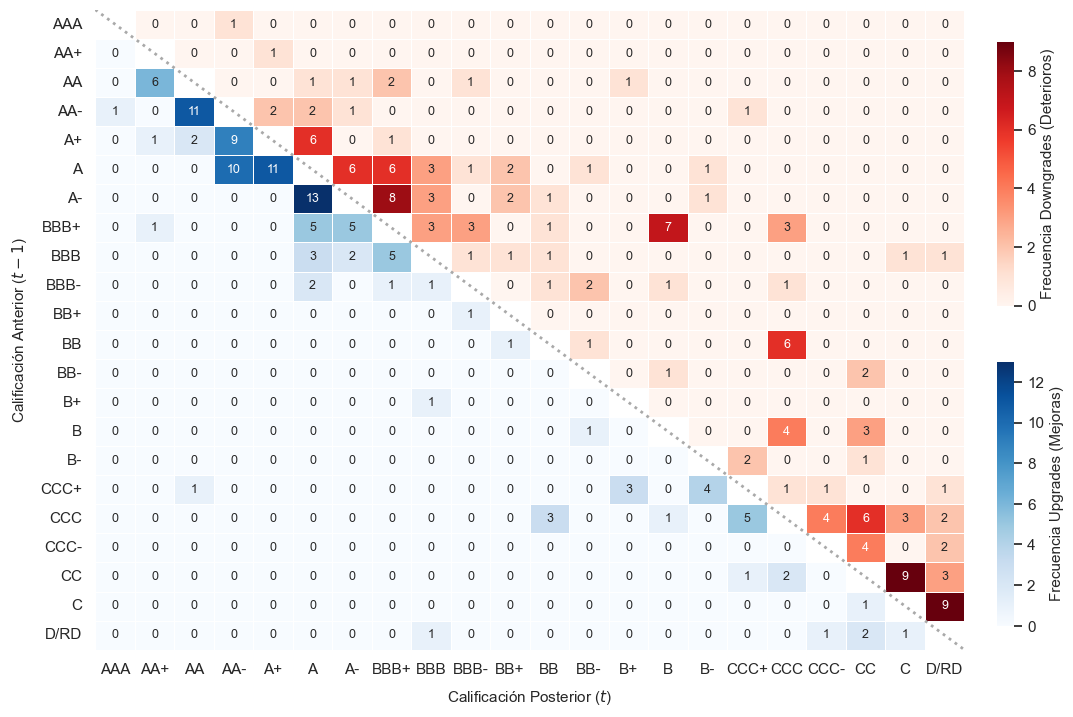

In [1072]:
graficar_heatmap_transiciones_fix(df_final)

In [1073]:
df_final['fecha_consejo'].min()

Timestamp('2022-05-03 00:00:00')

In [1074]:
df_final['fecha_consejo'].max()

Timestamp('2026-05-04 00:00:00')

# Actividades Economicas (AFIP)

In [1075]:
actividades = pd.read_csv("/Users/sofiascaiano/Documents/maestria/TT1/project/actividad_afip/data/output/actividades_economicas.csv")
actividades = actividades[actividades['es_actividad_principal'] == 1]
clae = pd.read_csv("/Users/sofiascaiano/Documents/maestria/TT1/project/actividad_afip/data/output/clae_afip.csv")

In [1076]:
clae.head()

,seccion,grupo,subgrupo,descripcion
0,A,NaN,NaN,"AGRICULTURA, GANADERÍA, CAZA, SILVICULTURA Y P..."
1,A,1.0,NaN,"Agricultura, ganadería, caza y servicios agríc..."
2,A,1.0,11.0,Cultivos temporales
3,A,1.0,12.0,Cultivos perennes
4,A,1.0,13.0,"Propagación de plantas (Viveros, excepto fores..."


In [1077]:
actividades.info()

<class 'pandas.DataFrame'>
Index: 166 entries, 23 to 1495
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   cuit_consultado         166 non-null    int64
 1   id_actividad            166 non-null    int64
 2   descripcion             166 non-null    str  
 3   nomenclador             166 non-null    int64
 4   orden                   166 non-null    int64
 5   periodo                 166 non-null    int64
 6   regimen                 166 non-null    str  
 7   es_actividad_principal  166 non-null    int64
dtypes: int64(6), str(2)
memory usage: 11.7 KB


In [1078]:
df_final_actividades = pd.merge(df_final, actividades[['cuit_consultado', 'id_actividad', 'descripcion']], how='left', left_on='cuit', right_on='cuit_consultado')

In [1079]:
df_final_actividades[df_final_actividades['id_actividad'].isna()]

,cuit,razon_social,calificadora,fecha_consejo,presentacion_id,instrumento,moneda_a_calificar,calificacion_categoria,calificacion_signo,rating_watch,...,tiene_signo,nota_limpia_final,periodo_mensual,rating_num,delta_notches,evento_crediticio,rating_num_anterior,cuit_consultado,id_actividad,descripcion
346,30504077079,Pecom Energia S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2024-09-25,3258349.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(arg),-,0,...,False,AA-,2024-09,19.0,NaN,Inicio,NaN,NaN,NaN,NaN
620,30527677331,IRSA Propiedades Comerciales S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2022-06-01,2901391.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(ARG),NaN,0,...,False,AA,2022-06,20.0,NaN,Inicio,NaN,NaN,NaN,NaN
2560,30716342804,CP MANQUE S.A.U.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2022-07-21,2921965.0,NaN,DÓLAR (E.U.A.),LARGO / NACIONAL / A(ARG),+,0,...,False,A+,2022-07,18.0,NaN,Inicio,NaN,NaN,NaN,NaN
2561,30716342863,CP LOS OLIVOS S.A.U.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2022-10-24,2959340.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(ARG),-,0,...,False,AA-,2022-10,19.0,NaN,Inicio,NaN,NaN,NaN,NaN
2844,34615368298,SIDERSA S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2024-11-29,3287365.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / A(arg),+,0,...,False,A+,2024-11,18.0,NaN,Inicio,NaN,NaN,NaN,NaN
2845,34615368298,SIDERSA S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2026-03-27,3502374.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / A(arg),+,0,...,False,A+,2026-03,18.0,0.0,Mantiene,18.0,NaN,NaN,NaN


In [1080]:
df_final_actividades.info()

<class 'pandas.DataFrame'>
RangeIndex: 2854 entries, 0 to 2853
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   cuit                    2854 non-null   int64         
 1   razon_social            2854 non-null   str           
 2   calificadora            2854 non-null   str           
 3   fecha_consejo           2854 non-null   datetime64[us]
 4   presentacion_id         2854 non-null   float64       
 5   instrumento             2737 non-null   str           
 6   moneda_a_calificar      2854 non-null   str           
 7   calificacion_categoria  2854 non-null   str           
 8   calificacion_signo      766 non-null    str           
 9   rating_watch            2854 non-null   str           
 10  perspectiva             2854 non-null   str           
 11  plazo                   2854 non-null   str           
 12  escala                  2849 non-null   str           
 13 

In [1081]:
df_g = df_final_actividades[df_final_actividades['evento_crediticio'].isin(['Downgrade', 'Upgrade'])][['cuit', 'periodo_mensual', 'evento_crediticio']]

df_g.drop_duplicates(subset=['cuit', 'periodo_mensual', 'evento_crediticio'], inplace=True)

In [1082]:
# Aseguramos formato datetime
# df_final_actividades["periodo_mensual"] = pd.to_datetime(df_final_actividades["periodo_mensual"])

# 1. Separamos los eventos para no mezclar Upgrades con Downgrades en la precedencia
# (La consigna dice "un evento en la misma dirección")
edge_list_total = []

# Agrupamos por tipo de evento (Downgrade o Upgrade)
for evento, df_sub in df_g.groupby("evento_crediticio"):

    # Auto-merge para cruzar todos los eventos del mismo tipo
    merged = pd.merge(
        df_sub,
        df_sub,
        on="evento_crediticio",
        suffixes=("_A", "_B"),
    )

    # Filtrar 1: Evitar enlaces de una empresa consigo misma
    merged = merged[merged["cuit_A"] != merged["cuit_B"]]

    # Calcular la diferencia exacta en meses
    # Al restar Period[M], el resultado es un objeto de tipo pandas.Series de enteros (Int64)
    merged["diff_meses"] = (
        merged["periodo_mensual_B"] - merged["periodo_mensual_A"]
    ).apply(lambda x: x.n)

    # Filtrar 2: Ventana de observación asíncrona de 12 meses (0 < diff <= 12)
    valid_edges = merged[
        (merged["diff_meses"] > 0) & (merged["diff_meses"] <= 12)
    ].copy()

    # 2. Calcular el peso con la función de decaimiento temporal
    # Calibramos lambda para que a los 12 meses el peso disminuya significativamente
    lmbda = 0.2
    valid_edges["weight"] = np.exp(-lmbda * valid_edges["diff_meses"])

    # Estructurar las columnas para el formato del grafo
    edges = valid_edges[
        ["cuit_A", "periodo_mensual_A", "cuit_B", "weight", "evento_crediticio"]
    ].rename(columns={"cuit_A": "source", "cuit_B": "target"})

    edge_list_total.append(edges)

# Consolidar todos los enlaces en un único DataFrame
final_edge_list = pd.concat(edge_list_total, ignore_index=True)

grafo_input = (
    final_edge_list.groupby(
        ["source", "periodo_mensual_A", "target", "evento_crediticio"]
    )["weight"]
    .max()
    .reset_index()
)

# Opcional: Reordenar columnas para que quede prolijo
grafo_input = grafo_input[
    ["source", "periodo_mensual_A", "target", "evento_crediticio", "weight"]
]

In [1083]:
df_final['fecha_consejo'].max()

Timestamp('2026-05-04 00:00:00')

In [1084]:
# Fijo un corte minimo
periodo_max_source = df_final['periodo_mensual'].max() - 4
print(periodo_max_source)

2026-01


In [1085]:
grafo_input = grafo_input[grafo_input['periodo_mensual_A'] <= periodo_max_source]

In [1086]:
grafo_input['evento_crediticio'].value_counts()

evento_crediticio
Upgrade      2671
Downgrade    1790
Name: count, dtype: int64

In [1087]:
grafo_input.to_csv("input_grafo.csv", index=False)

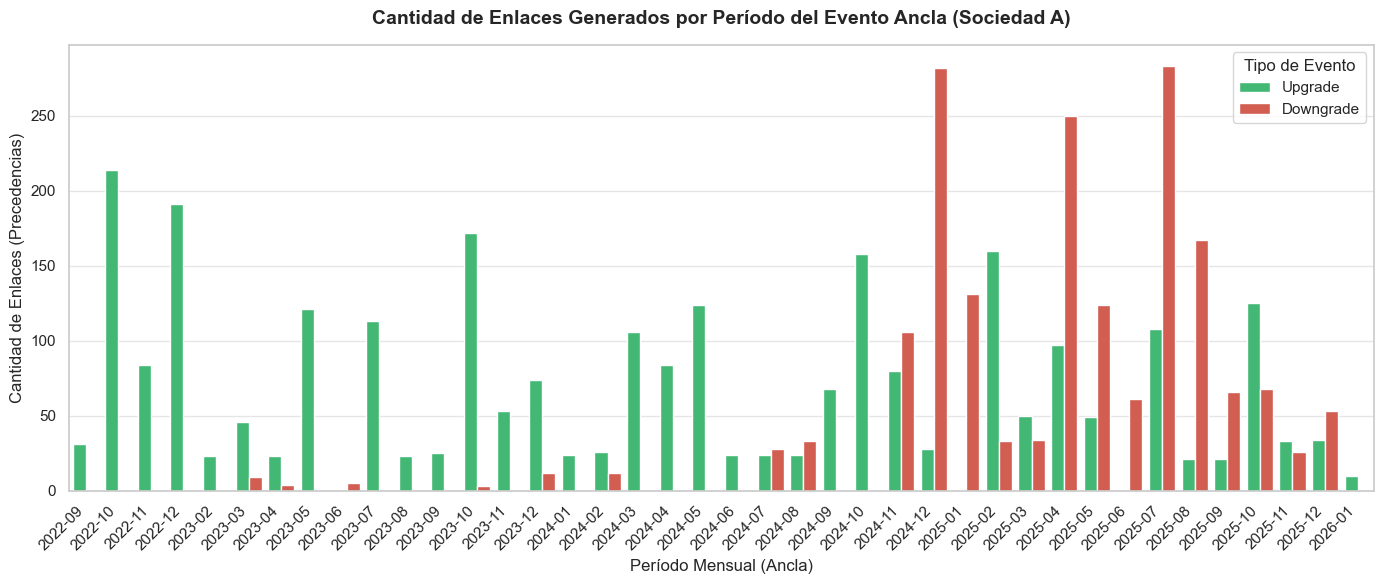

In [1088]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos: convertimos el Period[M] a string y ordenamos cronológicamente
df_plot = grafo_input.copy()
df_plot["periodo_mensual_A_str"] = df_plot["periodo_mensual_A"].astype(str)
df_plot = df_plot.sort_values("periodo_mensual_A")

# 2. Configurar el tamaño y estilo del gráfico
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# 3. Crear el countplot
# Usamos 'hue' para separar visualmente la cantidad de Downgrades y Upgrades por mes
ax = sns.countplot(
    data=df_plot,
    x="periodo_mensual_A_str",
    hue="evento_crediticio",
    palette={"Downgrade": "#e74c3c", "Upgrade": "#2ecc71"},
)

# 4. Estética del gráfico
plt.title(
    "Cantidad de Enlaces Generados por Período del Evento Ancla (Sociedad A)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Período Mensual (Ancla)", fontsize=12)
plt.ylabel("Cantidad de Enlaces (Precedencias)", fontsize=12)

# Rotar las etiquetas del eje X para que no se superpongan si tenés muchos meses
plt.xticks(rotation=45, ha="right")

# Ajustar la leyenda
plt.legend(title="Tipo de Evento", frameon=True)

# Optimizar el espacio para que no se corten las etiquetas del eje X
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [1089]:
df_final[(df_final['cuit'] == 30999027489)].sort_values(by=['calificadora', 'moneda_a_calificar', 'plazo', 'fecha_consejo'])

,cuit,razon_social,calificadora,fecha_consejo,presentacion_id,instrumento,moneda_a_calificar,calificacion_categoria,calificacion_signo,rating_watch,...,escala,nota_sucia,nota_limpia,tiene_signo,nota_limpia_final,periodo_mensual,rating_num,delta_notches,evento_crediticio,rating_num_anterior
3174,30999027489,Empresa Provincial de Energía de Córdoba,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2022-12-28,2988187.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(ARG),NaN,0,...,NACIONAL,AA(ARG),AA,False,AA,2022-12,20.0,NaN,Inicio,17.0
3171,30999027489,Empresa Provincial de Energía de Córdoba,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-04-21,3033921.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(ARG),NaN,0,...,NACIONAL,AA(ARG),AA,False,AA,2023-04,20.0,0.0,Mantiene,17.0
3168,30999027489,Empresa Provincial de Energía de Córdoba,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-07-28,3072397.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(arg),NaN,0,...,NACIONAL,AA(arg),AA,False,AA,2023-07,20.0,0.0,Mantiene,17.0
3165,30999027489,Empresa Provincial de Energía de Córdoba,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-11-30,3122958.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(arg),NaN,0,...,NACIONAL,AA(arg),AA,False,AA,2023-11,20.0,0.0,Mantiene,20.0
3162,30999027489,Empresa Provincial de Energía de Córdoba,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-12-28,3133187.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(arg),NaN,0,...,NACIONAL,AA(arg),AA,False,AA,2023-12,20.0,0.0,Mantiene,17.0
3157,30999027489,Empresa Provincial de Energía de Córdoba,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2024-08-30,3246469.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(arg),-,0,...,NACIONAL,AA(arg),AA,False,AA-,2024-08,19.0,-1.0,Downgrade,17.0
3156,30999027489,Empresa Provincial de Energía de Córdoba,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2024-11-06,3276636.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(arg),-,0,...,NACIONAL,AA(arg),AA,False,AA-,2024-11,19.0,0.0,Mantiene,19.0
3149,30999027489,Empresa Provincial de Energía de Córdoba,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-05-30,3369152.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(arg),-,0,...,NACIONAL,AA(arg),AA,False,AA-,2025-05,19.0,0.0,Mantiene,17.0
3146,30999027489,Empresa Provincial de Energía de Córdoba,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-07-31,3395426.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(arg),-,0,...,NACIONAL,AA(arg),AA,False,AA-,2025-07,19.0,0.0,Mantiene,17.0
3145,30999027489,Empresa Provincial de Energía de Córdoba,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2025-10-31,3435456.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(arg),-,0,...,NACIONAL,AA(arg),AA,False,AA-,2025-10,19.0,0.0,Mantiene,19.0


In [1092]:
df_final[(df_final['instrumento'].str.contains('corto')) & (df_final['plazo'] == 'LARGO')]

,cuit,razon_social,calificadora,fecha_consejo,presentacion_id,instrumento,moneda_a_calificar,calificacion_categoria,calificacion_signo,rating_watch,...,escala,nota_sucia,nota_limpia,tiene_signo,nota_limpia_final,periodo_mensual,rating_num,delta_notches,evento_crediticio,rating_num_anterior
1341,30629827060,Capex S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2024-12-27,3298826.0,emisorasacortoplazo,PESO (ARGENTINA),LARGO / NACIONAL / AA(arg),NaN,0,...,NACIONAL,AA(arg),AA,False,AA,2024-12,20.0,0.0,Mantiene,9.0
8810,33515950899,VISTA OIL & GAS ARGENTINA S.A.U,MOODY´S LOCAL AR ACR S.A.,2024-09-30,3259904.0,emisorasacortoplazo,DÓLAR (E.U.A.),LARGO / NACIONAL / AAA.ar,NaN,0,...,NACIONAL,AAA.ar,AAA,False,AAA,2024-09,23.0,0.0,Mantiene,23.0


In [1093]:
df_final[(df_final['instrumento'].str.contains('largo')) & (df_final['plazo'] == 'CORTO')]

,cuit,razon_social,calificadora,fecha_consejo,presentacion_id,instrumento,moneda_a_calificar,calificacion_categoria,calificacion_signo,rating_watch,...,escala,nota_sucia,nota_limpia,tiene_signo,nota_limpia_final,periodo_mensual,rating_num,delta_notches,evento_crediticio,rating_num_anterior


In [1098]:
grafo_input[(grafo_input['source'] == 33715827129) & (grafo_input['evento_crediticio'] == 'Downgrade')]

,source,periodo_mensual_A,target,evento_crediticio,weight
4446,33715827129,2023-03,30511190238,Downgrade,0.548812
4447,33715827129,2023-03,30638375628,Downgrade,0.548812
4448,33715827129,2023-03,30655116202,Downgrade,0.548812
4449,33715827129,2023-03,30690076043,Downgrade,0.246597
4450,33715827129,2023-04,30511190238,Downgrade,0.670320
4451,33715827129,2023-04,30638375628,Downgrade,0.670320
4452,33715827129,2023-04,30655116202,Downgrade,0.670320
4453,33715827129,2023-04,30690076043,Downgrade,0.301194


In [1099]:
grafo_input[(grafo_input['target'] == 30638375628) & (grafo_input['evento_crediticio'] == 'Downgrade')]

,source,periodo_mensual_A,target,evento_crediticio,weight
626,30511190238,2023-06,30638375628,Downgrade,0.201897
1530,30629827060,2023-03,30638375628,Downgrade,0.548812
1829,30655116202,2023-06,30638375628,Downgrade,0.201897
2672,30690076043,2023-10,30638375628,Downgrade,0.449329
2707,30690076043,2023-12,30638375628,Downgrade,0.670320
4447,33715827129,2023-03,30638375628,Downgrade,0.548812
4451,33715827129,2023-04,30638375628,Downgrade,0.670320


In [1105]:
df_final[df_final['cuit'] == 30501062150]

,cuit,razon_social,calificadora,fecha_consejo,presentacion_id,instrumento,moneda_a_calificar,calificacion_categoria,calificacion_signo,rating_watch,...,escala,nota_sucia,nota_limpia,tiene_signo,nota_limpia_final,periodo_mensual,rating_num,delta_notches,evento_crediticio,rating_num_anterior
1737,30501062150,Celulosa Argentina,MOODY´S LOCAL AR ACR S.A.,2023-04-18,3030455.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / BBB.ar,NaN,0,...,NACIONAL,BBB.ar,BBB,False,BBB,2023-04,14.0,NaN,Inicio,NaN
1740,30501062150,Celulosa Argentina,MOODY´S LOCAL AR ACR S.A.,2023-04-18,3030455.0,emisorasalargoplazo,DÓLAR (E.U.A.),LARGO / NACIONAL / BBB-.ar,NaN,0,...,NACIONAL,BBB-.ar,BBB-,True,BBB-,2023-04,13.0,NaN,Inicio,NaN
1731,30501062150,Celulosa Argentina,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-05-05,3041789.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / BBB(ARG),-,0,...,NACIONAL,BBB(ARG),BBB,False,BBB-,2023-05,13.0,NaN,Inicio,14.0
1724,30501062150,Celulosa Argentina,MOODY´S LOCAL AR ACR S.A.,2023-10-04,3098556.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / BBB+.ar,NaN,0,...,NACIONAL,BBB+.ar,BBB+,True,BBB+,2023-10,15.0,1.0,Upgrade,13.0
1728,30501062150,Celulosa Argentina,MOODY´S LOCAL AR ACR S.A.,2023-10-04,3098556.0,emisorasalargoplazo,DÓLAR (E.U.A.),LARGO / NACIONAL / BBB.ar,NaN,0,...,NACIONAL,BBB.ar,BBB,False,BBB,2023-10,14.0,1.0,Upgrade,13.0
1717,30501062150,Celulosa Argentina,MOODY´S LOCAL AR ACR S.A.,2023-12-06,3124803.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / BBB+.ar,NaN,0,...,NACIONAL,BBB+.ar,BBB+,True,BBB+,2023-12,15.0,0.0,Mantiene,15.0
1721,30501062150,Celulosa Argentina,MOODY´S LOCAL AR ACR S.A.,2023-12-06,3124803.0,emisorasalargoplazo,DÓLAR (E.U.A.),LARGO / NACIONAL / BBB.ar,NaN,0,...,NACIONAL,BBB.ar,BBB,False,BBB,2023-12,14.0,0.0,Mantiene,14.0
1711,30501062150,Celulosa Argentina,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-12-22,3131333.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / BBB(arg),-,0,...,NACIONAL,BBB(arg),BBB,False,BBB-,2023-12,13.0,0.0,Mantiene,15.0
1704,30501062150,Celulosa Argentina,MOODY´S LOCAL AR ACR S.A.,2024-03-06,3161958.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / BBB+.ar,NaN,0,...,NACIONAL,BBB+.ar,BBB+,True,BBB+,2024-03,15.0,0.0,Mantiene,13.0
1708,30501062150,Celulosa Argentina,MOODY´S LOCAL AR ACR S.A.,2024-03-06,3161958.0,emisorasalargoplazo,DÓLAR (E.U.A.),LARGO / NACIONAL / BBB+.ar,NaN,0,...,NACIONAL,BBB+.ar,BBB+,True,BBB+,2024-03,15.0,1.0,Upgrade,14.0


In [1103]:
df_final[(df_final['evento_crediticio'] == 'Downgrade') & (df_final['periodo_mensual'] <= '2024-06')].sort_values(by='fecha_consejo')

,cuit,razon_social,calificadora,fecha_consejo,presentacion_id,instrumento,moneda_a_calificar,calificacion_categoria,calificacion_signo,rating_watch,...,escala,nota_sucia,nota_limpia,tiene_signo,nota_limpia_final,periodo_mensual,rating_num,delta_notches,evento_crediticio,rating_num_anterior
1292,33715827129,CAPETROL S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-03-14,3017019.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / CCC(ARG),NaN,2-Negativa,...,NACIONAL,CCC(ARG),CCC,False,CCC,2023-03,5.0,-8.0,Downgrade,13.0
1414,30629827060,Capex S.A.,"S&P GLOBAL RATINGS ARGENTINA SRL, AGENTE DE CA...",2023-03-31,3023475.0,NaN,PESO (ARGENTINA),LARGO / NACIONAL / CCC,+,0,...,NACIONAL,CCC,CCC,False,CCC+,2023-03,6.0,-7.0,Downgrade,19.0
1290,33715827129,CAPETROL S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-04-21,3033969.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / C(ARG),NaN,0,...,NACIONAL,C(ARG),C,False,C,2023-04,2.0,-3.0,Downgrade,5.0
7456,30638375628,ROCH S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-06-02,3056173.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / CC(arg),NaN,0,...,NACIONAL,CC(arg),CC,False,CC,2023-06,3.0,-5.0,Downgrade,8.0
3096,30655116202,Empresa Distribuidora y Comercializadora Norte SA,"S&P GLOBAL RATINGS ARGENTINA SRL, AGENTE DE CA...",2023-06-07,3058372.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / CCC,NaN,0,...,NACIONAL,CCC,CCC,False,CCC,2023-06,5.0,-5.0,Downgrade,15.0
7657,30511190238,S.A. San Miguel A.G.I.C.I. y F.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-06-12,3058010.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / A(arg),-,0,...,NACIONAL,A(arg),A,False,A-,2023-06,16.0,-1.0,Downgrade,17.0
7454,30638375628,ROCH S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2023-06-26,3059053.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / C(arg),NaN,0,...,NACIONAL,C(arg),C,False,C,2023-06,2.0,-1.0,Downgrade,3.0
7913,30690076043,SION S.A.,MOODY´S LOCAL AR ACR S.A.,2023-10-05,3099054.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / A-.ar,NaN,0,...,NACIONAL,A-.ar,A-,True,A-,2023-10,16.0,-1.0,Downgrade,17.0
7900,30690076043,SION S.A.,MOODY´S LOCAL AR ACR S.A.,2023-12-13,3127163.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / A-.ar,NaN,0,...,NACIONAL,A-.ar,A-,True,A-,2023-12,16.0,-1.0,Downgrade,17.0
7448,30638375628,ROCH S.A.,FIX SCR S.A. AGENTE DE CALIFICACIÓN DE RIESGO,2024-02-14,3152199.0,emisorasalargoplazo,PESO (ARGENTINA),LARGO / NACIONAL / D(ARG),NaN,0,...,NACIONAL,D(ARG),D,False,D,2024-02,1.0,-1.0,Downgrade,2.0
